# Ejercicio 1

## 1.1 Práctica con OpenStreetMap

In [1]:
# Ejecutar librerias
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt

# Ejemplo: obtener límites de áreas protegidas en el Amazonas peruano
query = 'boundary=protected_area'
peru_polygon = ox.geocode_to_gdf('Amazonas, Peru')
protected_areas = ox.features_from_polygon(peru_polygon.geometry[0], tags={"boundary": "protected_area"})

# Guardar en archivo para uso posterior
protected_areas.to_file("protected_areas.geojson", driver="GeoJSON")


c:\Users\HP\anaconda3\envs\hw4\lib\site-packages\osmnx\_overpass.py:211: UserWarning: This area is 21 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


                                                                geometry  \
element_type osmid                                                         
relation     9766619   POLYGON ((-77.77104 -6.36110, -77.77063 -6.360...   
             9768367   POLYGON ((-77.74500 -6.69195, -77.74060 -6.692...   
             9769525   POLYGON ((-77.99862 -6.96667, -77.99888 -6.966...   
             10872553  POLYGON ((-77.63319 -6.90992, -77.63211 -6.910...   
             12246837  POLYGON ((-78.03579 -6.74260, -78.03577 -6.743...   

                                                                   nodes  \
element_type osmid                                                         
relation     9766619   [[[6598008133, 6598008134, 6598008135, 6598008...   
             9768367   [[[6600735118, 6600735119, 6600735120, 6600735...   
             9769525   [[[6601643643, 6601643644, 6601643645, 6601643...   
             10872553  [[[3912474299, 7315278461, 7315278460, 7315278...   
           

c:\Users\HP\anaconda3\envs\hw4\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


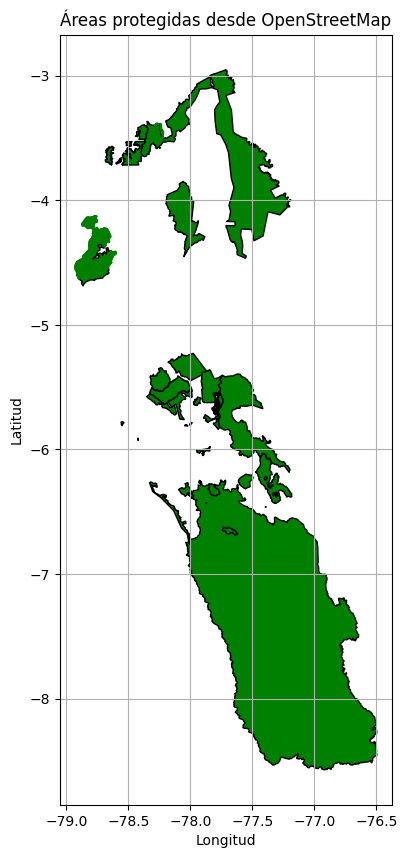

In [ ]:



# Asegúrate de que 'protected_areas' es un GeoDataFrame
print(protected_areas.head())  # Verifica que tiene geometría

# Visualización básica
protected_areas.plot(figsize=(10, 10), color='green', edgecolor='black')
plt.title("Áreas protegidas desde OpenStreetMap")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.grid(True)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_11924\2373056475.py:5: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


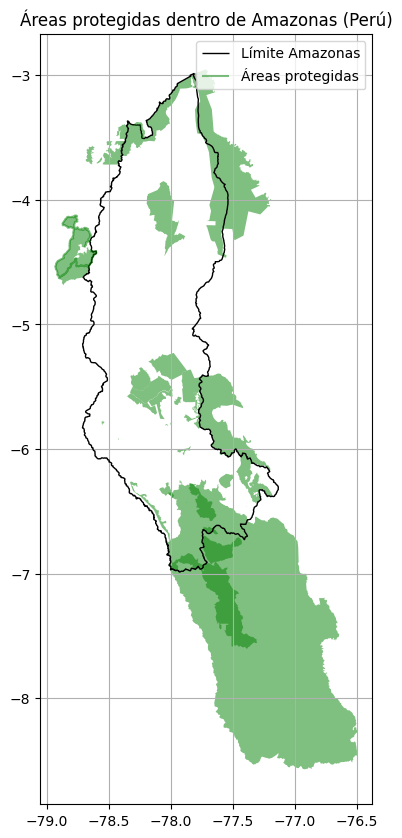

In [4]:
# Visualizar polígono base + áreas protegidas
fig, ax = plt.subplots(figsize=(10, 10))
peru_polygon.boundary.plot(ax=ax, color='black', linewidth=1, label='Límite Amazonas')
protected_areas.plot(ax=ax, color='green', alpha=0.5, label='Áreas protegidas')
plt.legend()
plt.title("Áreas protegidas dentro de Amazonas (Perú)")
plt.grid(True)
plt.show()


# 3.1 Acquire Peru’s protected-area polygons from OSM (25 pts) info

In [ ]:
# Configurar Overpass y logs
ox.settings.log_console = True
ox.settings.use_cache = False
ox.settings.timeout = 180  # segundos

# 1. Obtener polígono de Perú
print("📍 Descargando el polígono de Perú...")
peru = ox.geocode_to_gdf("Peru")

# 2. Consultar OSM con múltiples condiciones (logical OR)
print("🔎 Consultando áreas protegidas desde Overpass API...")
tags = {
    "boundary": "protected_area",
    "leisure": "nature_reserve",
    "protect_class": True  # el True significa "cualquier valor"
}

# Descarga todas las features que cumplan cualquiera de las condiciones
raw_gdf = ox.features_from_polygon(peru.geometry[0], tags=tags)

print(f"📦 Total de objetos descargados: {len(raw_gdf)}")

# 3. Filtrar tipos específicos de protección
# protect_class = 1: National Park, 2: Nature Reserve, 4: Forest Reserve, 5: Game Reserve, 6: Protected Landscape, etc.
valid_classes = {"1", "2", "4", "5", "6"}

# Algunos no tienen la columna protect_class; aseguramos que exista
if 'protect_class' not in raw_gdf.columns:
    raw_gdf['protect_class'] = None

# Filtrar solo los que están en las clases válidas
filtered_gdf = raw_gdf[raw_gdf['protect_class'].isin(valid_classes)]

print(f"✅ Filtrados {len(filtered_gdf)} polígonos con protect_class en {valid_classes}")

# 4. Guardar en GeoPackage
output_file = "peru_protected_areas.gpkg"
filtered_gdf.to_file(output_file, driver="GPKG")

print(f"💾 Guardado en: {output_file}")


📍 Descargando el polígono de Perú...
🔎 Consultando áreas protegidas desde Overpass API...


c:\Users\HP\anaconda3\envs\hw4\lib\site-packages\osmnx\_overpass.py:211: UserWarning: This area is 1,086 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


In [6]:
import os
import sys
import requests
from getpass import getpass
import zipfile
from io import BytesIO

import geopandas as gpd
import osmnx as ox
from bs4 import BeautifulSoup

import rasterio
import rioxarray as rxr
import xarray as xr
import numpy as np

In [25]:
import os
import glob
import rioxarray
import xarray as xr
import rasterio
import warnings
warnings.filterwarnings('ignore')

# 1. Configuración
HDF_FOLDER = "C:/Users/HP/Documents/GitHub/Data-Science-Python-UP/hw3/modishdf"
OUTPUT_TIF = "vcf_2024_peru.tif"

print("🚀 Iniciando procesamiento de datos MODIS VCF...")

# 2. Verificar archivos
hdf_files = glob.glob(os.path.join(HDF_FOLDER, "*.hdf"))
if not hdf_files:
    raise FileNotFoundError("❌ No hay archivos HDF en la carpeta.")

print(f"🔍 Se encontraron {len(hdf_files)} archivos HDF. Procesando...")

# 3. Función para encontrar y abrir tree cover
def open_tree_cover(hdf_file):
    """Intenta múltiples métodos para abrir la capa de tree cover"""
    
    # Método 1: Usando subdatasets de rasterio
    try:
        with rasterio.open(hdf_file) as src:
            subdatasets = src.subdatasets
            
        # Buscar subdataset de tree cover
        for subdataset in subdatasets:
            if any(keyword in subdataset.lower() for keyword in ['tree_cover', 'percent_tree', 'tree cover']):
                return rioxarray.open_rasterio(subdataset, masked=True)
                
    except Exception as e:
        print(f"   Método 1 falló: {e}")
    
    # Método 2: Formato HDF4 estándar para MOD44B
    hdf4_patterns = [
        f'HDF4_EOS:EOS_GRID:"{hdf_file}":MOD_Grid_VCF:Percent_Tree_Cover',
        f'HDF4_EOS:EOS_GRID:"{hdf_file}":Grid:Percent_Tree_Cover',
        f'HDF4_EOS:EOS_GRID:"{hdf_file}":MOD_Grid_VCF:Tree_Cover'
    ]
    
    for pattern in hdf4_patterns:
        try:
            return rioxarray.open_rasterio(pattern, masked=True)
        except Exception:
            continue
    
    # Método 3: Probar el primer subdataset (a veces es el único)
    try:
        with rasterio.open(hdf_file) as src:
            subdatasets = src.subdatasets
        if subdatasets:
            return rioxarray.open_rasterio(subdatasets[0], masked=True)
    except Exception:
        pass
    
    # Método 4: Intentar abrir directamente
    try:
        return rioxarray.open_rasterio(hdf_file, masked=True)
    except Exception:
        pass
    
    return None

# 4. Procesar archivos
dataarrays = []
failed_files = []

for i, hdf_file in enumerate(hdf_files, 1):
    print(f"📂 Procesando archivo {i}/{len(hdf_files)}: {os.path.basename(hdf_file)}")
    
    try:
        da = open_tree_cover(hdf_file)
        
        if da is not None and da.sizes.get('x', 0) > 0 and da.sizes.get('y', 0) > 0:
            dataarrays.append(da)
            print(f"✅ Extraído exitosamente")
        else:
            print(f"⚠️ No se pudo extraer datos válidos")
            failed_files.append(hdf_file)
            
    except Exception as e:
        print(f"❌ Error: {e}")
        failed_files.append(hdf_file)

# 5. Verificar resultados
if not dataarrays:
    print("\n❌ DIAGNÓSTICO REQUERIDO")
    print("No se pudieron extraer datos de ningún archivo.")
    print("Ejecuta el código de diagnóstico primero para identificar las subcapas correctas.")
    
    # Mostrar información del primer archivo para diagnóstico
    sample_file = hdf_files[0]
    print(f"\n🔍 Información del primer archivo: {os.path.basename(sample_file)}")
    try:
        with rasterio.open(sample_file) as src:
            subdatasets = src.subdatasets
            print("Subdatasets disponibles:")
            for i, sub in enumerate(subdatasets[:5]):  # Primeros 5
                print(f"  {i+1}. {sub}")
    except Exception as e:
        print(f"Error accediendo a subdatasets: {e}")
    
    raise ValueError("❌ Ejecuta el código de diagnóstico para identificar subcapas correctas")

print(f"\n📊 Resumen:")
print(f"   • Archivos procesados exitosamente: {len(dataarrays)}")
print(f"   • Archivos con problemas: {len(failed_files)}")

# 6. Crear mosaico (resto del código igual)
print("\n🧩 Generando mosaico...")
try:
    mosaic = xr.combine_by_coords(dataarrays)
    print("✅ Mosaico creado con combine_by_coords")
except Exception as e:
    print(f"⚠️ Error con combine_by_coords: {e}")
    try:
        mosaic = xr.concat(dataarrays, dim='band').mean(dim='band', skipna=True)
        print("✅ Mosaico creado con concatenación")
    except Exception as e2:
        raise ValueError(f"❌ No se pudo crear el mosaico: {e2}")

# 7. Información del mosaico
print(f"📏 Dimensiones del mosaico: {mosaic.sizes}")
print(f"📍 CRS actual: {mosaic.rio.crs}")
print(f"📈 Rango de valores: {float(mosaic.min()):.1f} - {float(mosaic.max()):.1f}")

# 8. Reproyectar y guardar
print("\n🌍 Reproyectando a EPSG:4326...")
try:
    reprojected = mosaic.rio.reproject("EPSG:4326")
    print("✅ Reproyección completada")
except Exception as e:
    print(f"⚠️ Error en reproyección: {e}")
    reprojected = mosaic

print(f"\n💾 Guardando como {OUTPUT_TIF}...")
reprojected.rio.to_raster(OUTPUT_TIF, driver="GTiff", compress='lzw')
print("✅ Archivo guardado exitosamente")

file_size = os.path.getsize(OUTPUT_TIF) / (1024*1024)
print(f"📁 Tamaño del archivo: {file_size:.1f} MB")
print("\n🎉 Proceso completado exitosamente!")

🚀 Iniciando procesamiento de datos MODIS VCF...
🔍 Se encontraron 5 archivos HDF. Procesando...
📂 Procesando archivo 1/5: MOD44B.A2023065.h09v09.061.2024128174108.hdf
   Método 1 falló: 'C:/Users/HP/Documents/GitHub/Data-Science-Python-UP/hw3/modishdf/MOD44B.A2023065.h09v09.061.2024128174108.hdf' not recognized as a supported file format.
⚠️ No se pudo extraer datos válidos
📂 Procesando archivo 2/5: MOD44B.A2023065.h10v09.061.2024128174145.hdf
   Método 1 falló: 'C:/Users/HP/Documents/GitHub/Data-Science-Python-UP/hw3/modishdf/MOD44B.A2023065.h10v09.061.2024128174145.hdf' not recognized as a supported file format.
⚠️ No se pudo extraer datos válidos
📂 Procesando archivo 3/5: MOD44B.A2023065.h10v10.061.2024128174658.hdf
   Método 1 falló: 'C:/Users/HP/Documents/GitHub/Data-Science-Python-UP/hw3/modishdf/MOD44B.A2023065.h10v10.061.2024128174658.hdf' not recognized as a supported file format.
⚠️ No se pudo extraer datos válidos
📂 Procesando archivo 4/5: MOD44B.A2023065.h11v09.061.202412817

ValueError: ❌ Ejecuta el código de diagnóstico para identificar subcapas correctas

   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ----------------------- ---------------- 1.6/2.7 MB 10.5 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 9.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


c:\Users\HP\anaconda3\envs\hw4\lib\site-packages\IPython\utils\_process_win32.py:124: ResourceWarning: unclosed file <_io.BufferedWriter name=3>
  return process_handler(cmd, _system_body)
c:\Users\HP\anaconda3\envs\hw4\lib\site-packages\IPython\utils\_process_win32.py:124: ResourceWarning: unclosed file <_io.BufferedReader name=4>
  return process_handler(cmd, _system_body)
c:\Users\HP\anaconda3\envs\hw4\lib\site-packages\IPython\utils\_process_win32.py:124: ResourceWarning: unclosed file <_io.BufferedReader name=5>
  return process_handler(cmd, _system_body)
